Methira Binath kahawita
w2119674

Data Handling
Loading the Dataset and all the libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
import pandas as pd
data_frame = pd.read_csv("/content/loan_approval_data (1).csv")



understand the data

In [ ]:
# Check structure
data_frame.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


In [ ]:
# Summary statistics
data_frame.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


edit the employement length misspelling colummn name

In [ ]:
data_frame.rename(columns={'emplyment_length': 'employment_length'}, inplace=True)


list the column names

In [ ]:
#the column  names

list(data_frame.columns)

['id',
 'age',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

It flips the values in loan_approval_status, turning 0 into 1 and 1 into 0.

In [ ]:
data_frame['loan Approval Status'] = 1 - data_frame['loan_approval_status']


checking hpw may loan aprroval status are 1 and 0

In [ ]:
data_frame['loan Approval Status'].value_counts()

,count
loan Approval Status,
1,50295
0,8350


loan aproval status graph usinmg seaborn dat avisualisatio library

<Axes: xlabel='loan_approval_status', ylabel='count'>

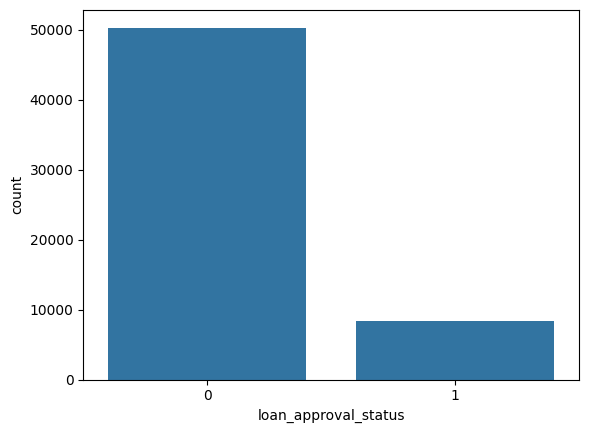

In [ ]:
import seaborn as sns
sns.countplot(x='loan_approval_status', data=data_frame)

In [ ]:
data_frame.head()


,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,loan Approval Status
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900,1
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739,1
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000,1
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000,1
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000,1


identify missing values

In [ ]:
data_frame.isnull().sum()

,0
id,0
age,6
income,0
home_ownership,0
employment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


find invalid rows
report commands

Find Exact Non Numeric Values

In [ ]:


columns = [
    'income',
    'age',
    'loan_amount',
    'loan_interest_rate',
    'loan_income_ratio',
    'credit_history_length',
    'loan_approval_status',
    'max_allowed_loan',
    'employment_length'
]

for col in columns:
    temp = pd.to_numeric(data_frame[col], errors='coerce')

    non_numeric_rows = data_frame[temp.isna() & data_frame[col].notna()]

    print(f"\nColumn: {col}")
    print("Non-numeric values found:", len(non_numeric_rows))

    if len(non_numeric_rows) > 0:
        print(non_numeric_rows[[col]].head())



Column: income
Non-numeric values found: 0

Column: age
Non-numeric values found: 0

Column: loan_amount
Non-numeric values found: 0

Column: loan_interest_rate
Non-numeric values found: 0

Column: loan_income_ratio
Non-numeric values found: 0

Column: credit_history_length
Non-numeric values found: 0

Column: loan_approval_status
Non-numeric values found: 0

Column: max_allowed_loan
Non-numeric values found: 0

Column: employment_length
Non-numeric values found: 0


-----------------------------------------------------------

Handle missing values (IMPUTATION)


 Identify column types

In [ ]:
num_cols = data_frame.select_dtypes(include=["int64", "float64"]).columns
cat_cols = data_frame.select_dtypes(include=["object"]).columns

replacing the misssing values with imputation


In [ ]:
# Numerical → median
for col in num_cols:
    data_frame[col] = data_frame[col].fillna(data_frame[col].median())

# Categorical → mode
for col in cat_cols:
    data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])

after fixing the missing values

In [ ]:
data_frame.isnull().sum()

,0
id,0
age,0
income,0
home_ownership,0
employment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,0
loan_income_ratio,0
payment_default_on_file,0


looping through the selcted coluymns and creating box plot for each one

In [ ]:

import plotly.express as plt

columns = ['age', 'max_allowed_loan', 'loan_interest_rate', 'employment_length']

for col in columns:
  plot = plt.box(data_frame,x=col)
  plot.show()

Detect lower bound and upperbound
This will calculate lower and upper bounds for each column.

In [ ]:
columns = ['age', 'max_allowed_loan', 'loan_interest_rate','employment_length']

for col in columns:
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


Column: age
Lower Bound: 12.5
Upper Bound: 40.5

Column: max_allowed_loan
Lower Bound: -44066.5
Upper Bound: 174785.5

Column: loan_interest_rate
Lower Bound: 0.21499999999999897
Upper Bound: 20.655

Column: employment_length
Lower Bound: -5.5
Upper Bound: 14.5


Show Rows That Are Outliers

In [ ]:
columns = ['age', 'max_allowed_loan', 'loan_interest_rate', 'employment_length']

for col in columns:
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_frame[
        (data_frame[col] < lower_bound) |
        (data_frame[col] > upper_bound)
    ]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]])


Outliers in age:
        age
8334   41.0
8335   41.0
8336   41.0
8337   41.0
8338   41.0
...     ...
58602  43.0
58608  42.0
58613  55.0
58614  42.0
58615  43.0

[2446 rows x 1 columns]

Outliers in max_allowed_loan:
       max_allowed_loan
0              -2426900
1               -111739
2                -89000
56415            174791
56416            174817
...                 ...
58640           1903960
58641           1909968
58642           2088491
58643           2291708
58644           2638778

[2233 rows x 1 columns]

Outliers in loan_interest_rate:
       loan_interest_rate
727                 21.36
741                 21.21
783                 21.74
1478                23.06
1969                21.74
2123                21.36
2166                21.21
2837                20.86
2842                20.89
3198                20.69
3801                21.36
4232                20.86
4234                20.80
4815                21.21
6303                20.89
6550                

identify the invalid max allowed loan and loan interest rate values


In [ ]:
invalid_rows = data_frame[
    (data_frame['max_allowed_loan'] < 0) |
    (data_frame['loan_interest_rate'] < 0)
]

print("Number of rows with negative values:", len(invalid_rows))
invalid_rows.head()

Number of rows with negative values: 4


,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,loan Approval Status
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900,1
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739,1
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000,1
8998,8185,21.0,25000,OWN,5,VENTURE,6000,-11.14,0.23,N,3,0,20234,1


In [ ]:
invalid_rows = data_frame[
    (data_frame['max_allowed_loan'] < 0) |
    (data_frame['loan_interest_rate'] < 0)
]

print("Number of rows with negative values:", len(invalid_rows))
invalid_rows.head()


Number of rows with negative values: 4


,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,loan Approval Status
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900,1
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739,1
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000,1
8998,8185,21.0,25000,OWN,5,VENTURE,6000,-11.14,0.23,N,3,0,20234,1


removing the minus values of max alowed loan and minus loan interest rate

In [ ]:
data_frame = data_frame[
    (data_frame['max_allowed_loan'] >= 0) &
    (data_frame['loan_interest_rate'] >= 0)
]

print("New shape after cleaning:", data_frame.shape)


New shape after cleaning: (58641, 14)


In [ ]:
data_frame.shape

(58641, 14)

checking how many more invalidvalues of employment length is  exist


In [ ]:
invalid_employment = data_frame[
    data_frame['employment_length'] > 40
]

print("Number of rows with employment_length > 40:",
      len(invalid_employment))

invalid_employment.head()

Number of rows with employment_length > 40: 5


,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,loan Approval Status
6008,41079,28.0,60350,MORTGAGE,123,MEDICAL,25000,15.95,0.35,Y,6,1,0,0
9479,11166,21.0,24000,RENT,150,MEDICAL,1500,14.27,0.06,Y,4,0,23692,1
37054,9997,58.0,48000,RENT,41,PERSONAL,7500,13.55,0.17,Y,24,0,76017,1
44566,26125,43.0,56000,RENT,41,HOMEIMPROVEMENT,2000,10.99,0.04,N,14,0,94315,1
56728,49252,21.0,192000,MORTGAGE,123,VENTURE,20000,11.49,0.10,N,2,0,181570,1


Remove those invalid employment lenngth rows

In [ ]:
data_frame = data_frame[
    data_frame['employment_length'] <= 40
]

print("New dataset shape:", data_frame.shape)

New dataset shape: (58636, 14)


identying the un real ages and removing them and keeping only the valid ages

In [ ]:
data_frame = data_frame[data_frame["age"] <= 100]

In [ ]:
data_frame = data_frame.drop('id', axis=1)
print("DataFrame shape after dropping 'id' column:", data_frame.shape)

encode  the categorical variables (Label Encoding)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    data_frame[col] = le.fit_transform(data_frame[col])

In [ ]:
data_frame.head()

,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,loan Approval Status
3,19180,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0,35000,1
4,28072,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0,35000,1
5,32074,40.0,131004,0,9,5,30000,7.90,0.23,0,13,0,30000,1
6,7224,40.0,150000,0,9,0,25000,11.89,0.17,0,11,0,25000,1
7,14471,40.0,132000,0,3,2,25000,16.82,0.22,0,17,0,25000,1


saving the cleaned data set

In [ ]:
data_frame.to_csv("loan_approval_data_cleaned.csv", index=False)

prepare the dats set for the calssification model

In [ ]:
# ================================
# CLASSIFICATION DATASET
# ================================

classification_data = data_frame.copy()

# Features and target
X_class = classification_data.drop(['loan_approval_status', 'max_allowed_loan'], axis=1)
y_class = classification_data['loan_approval_status']

# Show evidence
print("Classification Features:")
print(X_class.columns)

print("Classification Shape:", X_class.shape)

Classification Features:
Index(['id', 'age', 'income', 'home_ownership', 'employment_length',
       'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length',
       'loan Approval Status'],
      dtype='object')
Classification Shape: (58635, 12)


making the regression data set for the regression model

In [ ]:
# ================================
# REGRESSION DATASET
# ================================

# Keep only approved clients
regression_data = data_frame[data_frame['loan_approval_status'] == 1]

# Features and target
X_reg = regression_data.drop(['max_allowed_loan', 'loan_approval_status'], axis=1)
y_reg = regression_data['max_allowed_loan']

# Show evidence
print("Regression Features:")
print(X_reg.columns)

print("Regression Shape:", X_reg.shape)

Regression Features:
Index(['id', 'age', 'income', 'home_ownership', 'employment_length',
       'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length',
       'loan Approval Status'],
      dtype='object')
Regression Shape: (8349, 12)
